In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.spatial import cKDTree
import os

In [2]:
data_dir = "data/police-uk/archive-2025-12"
months = [f for f in os.listdir(data_dir) if f.startswith("2025") and os.path.isdir(os.path.join(data_dir, f))]
print(sorted(months))

['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']


In [3]:
months_locations = []
for m in months:
    locations = [os.path.join(data_dir, m, f) for f in os.listdir(os.path.join(data_dir, m)) if not (
        f.endswith("outcomes.csv") or f.endswith("stop-and-search.csv")
        )]
    months_locations += locations
print(sorted(months_locations))

['data/police-uk/archive-2025-12/2025-01/2025-01-avon-and-somerset-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-bedfordshire-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-btp-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-cambridgeshire-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-cheshire-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-city-of-london-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-cleveland-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-cumbria-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-derbyshire-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-devon-and-cornwall-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-dorset-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-durham-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-dyfed-powys-street.csv', 'data/police-uk/archive-2025-12/2025-01/2025-01-essex-stre

In [4]:
dfs = [pd.read_csv(fp) for fp in months_locations]
df = pd.concat(dfs, ignore_index=True)
df.shape

(5881375, 12)

In [5]:
print(f"England={df["LSOA code"].str.startswith("E").sum()}")
print(f"Wales={df["LSOA code"].str.startswith("W").sum()}")
print(f"Scotland={df["LSOA code"].str.startswith("S").sum()}")
print(f"Northern Ireland={df["LSOA code"].str.startswith("N").sum()}")

England=5382577
Wales=278266
Scotland=0
Northern Ireland=0


In [6]:
crime_types = df["Crime type"].unique()
print(crime_types)

<ArrowStringArray>
['Violence and sexual offences',    'Criminal damage and arson',
                 'Public order',                'Vehicle crime',
        'Anti-social behaviour',                     'Burglary',
                  'Other theft',                        'Drugs',
        'Possession of weapons',                  'Shoplifting',
                      'Robbery',                'Bicycle theft',
                  'Other crime',        'Theft from the person']
Length: 14, dtype: str


In [7]:
df = df.dropna(subset=["Longitude", "Latitude"]).reset_index(drop=True)
df.shape

(5795724, 12)

In [8]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326")
gdf = gdf.to_crs("EPSG:27700")
gdf.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,geometry
0,ba60ac4d46c57b26b37b3d52f96309af4a0ff909b6de6f...,2025-06,Surrey Police,Surrey Police,0.119928,51.559100,On or near Milner Road,E01000019,Barking and Dagenham 023A,Violence and sexual offences,Status update unavailable,NaN,POINT (547051.155 186597.863)
1,c2f8a9755a58f052e0bcd4eff60e6f08d11d29a23e66cd...,2025-06,Surrey Police,Surrey Police,-0.542479,51.079015,On or near Park/Open Space,E01031518,Chichester 002B,Criminal damage and arson,Unable to prosecute suspect,NaN,POINT (502195.272 132087.578)
2,9da133518902367f3cda673e9d0ff9024b4afc5719411b...,2025-06,Surrey Police,Surrey Police,-0.542479,51.079015,On or near Park/Open Space,E01031518,Chichester 002B,Criminal damage and arson,Unable to prosecute suspect,NaN,POINT (502195.272 132087.578)
3,492392a19ca510e3e1b777285018a13c2b091652771f45...,2025-06,Surrey Police,Surrey Police,-0.542479,51.079015,On or near Park/Open Space,E01031518,Chichester 002B,Criminal damage and arson,Unable to prosecute suspect,NaN,POINT (502195.272 132087.578)
4,cbe1a5ff7af2bde1a710fea58def37318274c146d0a144...,2025-06,Surrey Police,Surrey Police,-0.197082,51.160809,On or near Parking Area,E01031575,Crawley 001C,Public order,Unable to prosecute suspect,NaN,POINT (526166.055 141718.368)


In [9]:
oa_geo = gpd.read_file("data/spatial/OA/combined/uk_oa.gpkg")
oa_geo.head()

,OA,geometry
0,E00000001,"MULTIPOLYGON (((532303.492 181814.11, 532213.3..."
1,E00000003,"MULTIPOLYGON (((532213.378 181846.192, 532190...."
2,E00000005,"MULTIPOLYGON (((532180.131 181763.02, 532219.1..."
3,E00000007,"MULTIPOLYGON (((532201.292 181668.18, 532267.7..."
4,E00000010,"MULTIPOLYGON (((532127.958 182133.192, 532089...."


In [10]:
oa_geo = oa_geo[oa_geo["OA"].str.startswith("E") | oa_geo["OA"].str.startswith("W")].copy()
oa_geo.shape

(188880, 2)

## KNN distance

In [11]:
k = 10  # number of nearest crimes per OA
candidate_multiplier = 50  # candidates per OA fetched from the kd-tree before exact polygon distance

In [12]:
def compute_knn_mean_distance_polygon(
        oa_polygons, 
        crime_points, 
        k, 
        candidate_multiplier
        ):
    
    n = len(oa_polygons)
    if len(crime_points) == 0:
        return np.full(n, np.nan)

    crime_xy = np.column_stack([crime_points.x.values, crime_points.y.values])
    tree = cKDTree(crime_xy)

    centroids = oa_polygons.centroid
    centroid_xy = np.column_stack([centroids.x.values, centroids.y.values])

    k_query = min(max(k * candidate_multiplier, k), len(crime_xy))
    _, candidate_idx = tree.query(centroid_xy, k=k_query)
    if k_query == 1:
        candidate_idx = candidate_idx[:, None]

    crime_geoms = crime_points.values
    polygon_geoms = oa_polygons.values

    out = np.empty(n)
    for i in range(n):
        cands = crime_geoms[candidate_idx[i]]
        dists = np.fromiter(
            (polygon_geoms[i].distance(p) for p in cands),
            dtype=float,
            count=len(cands),
        )
        if len(dists) <= k:
            out[i] = dists.mean()
        else:
            out[i] = np.partition(dists, k - 1)[:k].mean()
    return out

In [13]:
oa_polygons = oa_geo.geometry
oa_polygons.shape

(188880,)

In [14]:
knn = {}
for c in crime_types:
    print(c, flush=True)
    c_gdf = gdf[gdf["Crime type"] == c]
    knn[c] = compute_knn_mean_distance_polygon(oa_polygons, c_gdf.geometry, k, candidate_multiplier)

Violence and sexual offences
Criminal damage and arson
Public order
Vehicle crime
Anti-social behaviour
Burglary
Other theft
Drugs
Possession of weapons
Shoplifting
Robbery
Bicycle theft
Other crime
Theft from the person


In [15]:
oa_knn = pd.DataFrame({"OA": oa_geo["OA"].astype(str).values})
for c in crime_types:
    oa_knn[c] = knn[c]
oa_knn.head()

,OA,Violence and sexual offences,Criminal damage and arson,Public order,Vehicle crime,Anti-social behaviour,Burglary,Other theft,Drugs,Possession of weapons,Shoplifting,Robbery,Bicycle theft,Other crime,Theft from the person
0,E00000001,16.454858,56.509467,16.454858,168.377731,73.374058,72.844540,20.393638,110.183128,472.211181,149.063011,154.148717,18.424248,211.319293,16.454858
1,E00000003,57.786531,87.012751,83.192884,112.587291,62.885916,94.270830,66.841576,92.817855,480.354533,194.653651,169.699889,60.953391,232.680469,58.502561
2,E00000005,54.232186,81.768596,97.751300,44.641863,44.066847,95.278798,50.608603,46.647317,466.432932,209.376347,166.883991,20.891886,220.732738,0.240273
3,E00000007,2.151943,28.591150,15.890814,5.534519,76.679491,16.222626,0.000000,10.774129,300.604263,5.654024,36.553267,5.615431,81.572229,0.000000
4,E00000010,11.224949,91.188203,90.734746,142.207720,77.369885,24.405391,26.281867,10.530854,381.951845,188.347709,98.367175,37.711455,289.186171,29.458771


In [16]:
oa_knn.describe()

,Violence and sexual offences,Criminal damage and arson,Public order,Vehicle crime,Anti-social behaviour,Burglary,Other theft,Drugs,Possession of weapons,Shoplifting,Robbery,Bicycle theft,Other crime,Theft from the person
count,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000
mean,118.432053,508.144129,537.324349,750.523368,497.698465,770.038798,478.669741,978.279862,1649.669630,1104.633317,2258.556560,2492.885561,807.217182,2693.485869
std,412.582214,1411.492261,1329.677346,1712.172109,1735.093264,1878.356214,1101.440914,1799.465758,2493.020320,2231.557616,3612.479351,3513.800794,1348.076452,3508.324133
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,42.180957,53.632989,63.417024,11.120170,102.083373,62.332245,123.624813,361.485014,154.112905,309.717082,464.033003,180.733605,527.319456
50%,5.884461,102.502378,126.719237,171.299726,52.156226,221.959661,142.199888,304.351036,676.123799,353.354193,755.287424,1014.761395,322.533431,1274.485606
75%,36.695209,243.864006,294.257011,469.792020,149.587223,494.734984,308.251408,779.013134,1604.802361,745.234135,2427.832106,2890.625234,654.414431,3474.307864
max,5235.463715,12478.690514,40143.395788,48563.057793,16462.996850,41151.775138,11877.640815,45353.884832,50954.470245,25441.903627,59843.058127,58449.796115,42246.140954,59781.556111


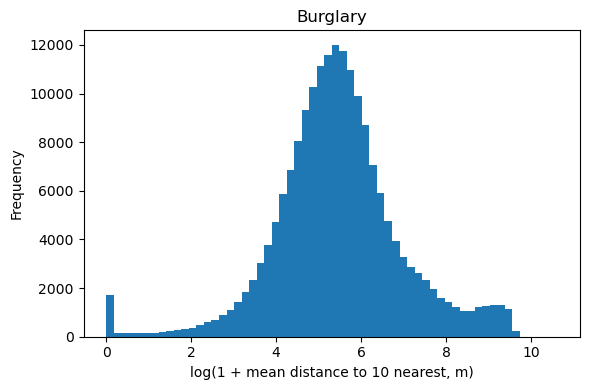

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log1p(oa_knn["Burglary"].values), bins=60)
ax.set_title("Burglary")
ax.set_xlabel(f"log(1 + mean distance to {k} nearest, m)")
ax.set_ylabel("Frequency")
fig.tight_layout()
plt.show()

In [18]:
oa_knn.set_index("OA", inplace=True)
oa_knn.to_parquet(f"data/police-uk/police-2025-ew-knn-k{k}-polygon.parquet")